In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import json
import pandas as pd
import os
import zipfile
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np

from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn as nn
import os, json
from transformers import CLIPModel, AutoModel, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

In [ ]:
!pip install -q pytorch-lightning==2.2.0 torchmetrics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.3/800.3 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 103.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.1 MB/s eta 0:00:00


In [ ]:
import torch

# enable TF32 on supported Tensor Cores for matmuls
torch.set_float32_matmul_precision('medium')   # or 'high' for more aggressive TF32 use

import pytorch_lightning as pl

In [ ]:
# Set dataset path
dataset_path = "/content/drive/My Drive/licenta/balanced"

# List available files
files = os.listdir(dataset_path)
print("Files in dataset:", files)

Files in dataset: ['test_balanced_questions.json', 'shortAnswer_translated.json', 'testdev_balanced_questions.json', 'train_balanced_questions.json', 'val_balanced_questions.json', 'train_subset_balanced.json', 'val_subset_balanced.json', 'train_top500_filtered.json', 'val_top500_filtered.json', 'test_top500_filtered.json', 'train_top500_subset.json', 'val_top500_subset.json', 'test_top500_subset.json', 'train_top500_100k.json', 'val_top500_balanced.json', 'test_top500_full.json', 'answer_vocab_top500.json', 'train_top100_shared_balanced.json', 'val_top100_shared_balanced.json', 'train_top100_cluster.json', 'val_top100_cluster.json', 'test_top100_shared_balanced.json', 'train_final.json']


In [ ]:
dataset_path = "/content/drive/My Drive/vqa_clean/new_data"

def load_dataset(json_path):
    json_path = os.path.join(dataset_path, json_path)
    with open(json_path, "r", encoding="utf-8") as f:
        data_json = json.load(f)
    df = pd.DataFrame.from_dict(data_json, orient="index")
    df["question"] = df["question"]
    df["answer"] = df["answer_clean"]
    df["imageId"] = df["imageId"]
    return df

train_df = load_dataset("train_all_clean_answer_bt_fixed.json")
val_df = load_dataset("val_all_clean_answer.json")
test_df = load_dataset("test_all_clean_answer.json")

In [ ]:
print(f"Train Samples: {len(train_df)}")
print(f"Val Samples:   {len(val_df)}")
print(f"Test Samples:  {len(test_df)}")

Train Samples: 943000
Val Samples:   132062
Test Samples:  12578


In [ ]:
import os
import zipfile

zip_path = "/content/drive/My Drive/licenta/images.zip"  # Adjust if different name
extract_path = "/content/data"  # Folder where you'll unzip

# Create the directory if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Extraction complete!


In [ ]:
import os

image_dir = "/content/data/images"

# 1. List all files in /content/data
all_files = os.listdir(image_dir)

# 2. Filter by image extensions
image_files = [f for f in all_files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]

# 3. Print stats
print(f"Total files in '{image_dir}': {len(all_files)}")
print(f"Total images (jpg/png/jpeg): {len(image_files)}")
print(f"First 5 images: {image_files[:5]}")

Total files in '/content/data/images': 148854
Total images (jpg/png/jpeg): 148854
First 5 images: ['n439542.jpg', '2319759.jpg', '2331067.jpg', '2371398.jpg', '2381381.jpg']


In [ ]:
extract_path = "/content/data"  # Folder where you'll unzip

In [ ]:
import pandas as pd
import numpy as np

# ──────────────────────────────────────────────────────────────
# 1️⃣  Canonicalise every answer cell to a single clean string
#     • pick first element if the cell is list/tuple/array
#     • strip whitespace, lower-case (optional)
# ──────────────────────────────────────────────────────────────
def canon(cell: object) -> str:
    if pd.isna(cell):
        return None                       # ignore true NaNs
    if isinstance(cell, (list, tuple, np.ndarray)):
        cell = cell[0]                    # keep first synonym
    return str(cell).strip()              # .lower() if you prefer

train_df["answer_c"] = train_df["answer"].map(canon)
val_df["answer_c"]   = val_df["answer"].map(canon)
test_df["answer_c"]  = test_df["answer"].map(canon)

# ──────────────────────────────────────────────────────────────
# 2️⃣  Build mapping from the union of *all three* splits
#     (first-seen order preserved)
# ──────────────────────────────────────────────────────────────
seen = {}
for col in [train_df["answer_c"], val_df["answer_c"], test_df["answer_c"]]:
    for a in col:
        if a is not None and a not in seen:
            seen[a] = len(seen)

answer2idx = seen                            # answer → int
idx2answer = dict(enumerate(seen))           # int    → answer

# Optional <UNK>
UNK_ID = len(answer2idx)
answer2idx["<UNK>"] = UNK_ID
idx2answer[UNK_ID]  = "<UNK>"

print(f"Total unique answers: {len(answer2idx)-1} (+1 UNK)")

# ──────────────────────────────────────────────────────────────
# 3️⃣  Attach integer label to every DataFrame
#     (unknowns mapped to UNK_ID)
# ──────────────────────────────────────────────────────────────
for df in (train_df, val_df, test_df):
    df["answer_id"] = df["answer_c"].map(answer2idx).fillna(UNK_ID).astype(int)


Total unique answers: 1733 (+1 UNK)


In [ ]:
all_answers = sorted(
    set(train_df["answer_clean"])
  | set(val_df  ["answer_clean"])
  | set(test_df ["answer_clean"])
)
answer2idx = {ans: i for i, ans in enumerate(all_answers)}
idx2answer = {i: ans for ans, i in answer2idx.items()}


In [ ]:
print("Number of classes:", len(answer2idx))
print("Example classes:", list(answer2idx.keys())[:10])


Number of classes: 1733
Example classes: ['a da mana', 'a inflori', 'a picta', 'aburi', 'aburit', 'acoperit', 'acoperit de nori', 'acoperiş', 'acvariu', 'adidas']


In [ ]:
from transformers import ViTModel, AutoTokenizer, AutoModel


In [ ]:
from torchvision.models import resnet101, ResNet101_Weights
from transformers import AutoTokenizer

# ─── 1) Prepare the ResNet101 preprocess pipeline ──────────────────────────
# This is exactly what the docs show:
weights = ResNet101_Weights.DEFAULT
resnet_preprocess = weights.transforms()  # Resize→Crop→ToTensor→Normalize

In [ ]:
class Config:
    text_model = "readerbench/RoBERT-base"
    vision_model = "microsoft/swin-base-patch4-window7-224"
    max_length = 128
    batch_size = 128
    num_epochs = 20  # Increased for early stopping
    learning_rate = 3e-5
    num_classes = 100
    patience = 2  # Early stopping patience
    scheduler_factor = 0.01  # LR reduction factor
    scheduler_threshold = 0.01 # Metric threshold
    min_lr = 1e-6  # Minimum learning rate

In [ ]:
import os
import random
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms

class VQADataset(Dataset):
    def __init__(self,
                 dataframe,
                 image_dir,
                 answer2idx,
                 tokenizer,
                 image_processor,
                 image_transform=None,
                 image_augment=None,
                 text_delete_prob: float = 0,
                 question_bt_prob: float = 0.0,   # ← new
                 tensor_augment=None,
                 syn_dict: dict = None,
                 syn_replace_prob: float = 0 ,
                 backtranslation_prob: float = 0.0):
        self.df                = dataframe.reset_index(drop=True)
        # …
        self.text_delete_prob  = text_delete_prob
        self.question_bt_prob  = question_bt_prob   # ← store it
        # …
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.answer2idx = answer2idx
        self.tokenizer = tokenizer
        self.image_processor = image_processor
        self.image_augment = image_augment
        self.text_delete_prob = text_delete_prob
        self.syn_dict = syn_dict or {}
        self.syn_replace_prob = syn_replace_prob
        self.tensor_augment = tensor_augment
        self.backtranslation_prob = backtranslation_prob

        # if image_transform is None:
        #     weights = ResNet101_Weights.DEFAULT
        #     image_transform = weights.transforms()        # resize → crop → toTensor → normalise
        self.image_transform = image_transform


    def __len__(self):
        return len(self.df)

    def _augment_text(self, question: str) -> str:
        """Existing: randomly delete tokens."""
        tokens = question.split()
        if not tokens:
            return question
        kept = [t for t in tokens if random.random() > self.text_delete_prob]
        if not kept:
            kept = [random.choice(tokens)]
        return " ".join(kept)

    def _synonym_replace(self, question: str) -> str:
        """New: randomly swap tokens for synonyms from syn_dict."""
        tokens = question.split()
        out = []
        for t in tokens:
            # if we have synonyms for t and coin flip succeeds
            if t in self.syn_dict and self.syn_dict[t] and random.random() < self.syn_replace_prob:
                out.append(random.choice(self.syn_dict[t]))
            else:
                out.append(t)
        return " ".join(out)


    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        # … image loading + augmentation as before …
         # --- Image processing (unchanged) ---
        image_path = os.path.join(self.image_dir, row["imageId"] + ".jpg")
        image = Image.open(image_path).convert("RGB")
        if self.image_augment:
            image = self.image_augment(image)
        #vit prerprocessor
        # image = self.image_processor(image, return_tensors="pt")["pixel_values"].squeeze(0)

        #resnet preprocessor
        # image = self.image_transform(image)  # returns a [3,224,224] tensor
         # 2) HF processor → {"pixel_values": Tensor[1,3,H,W], ...}
        proc_out     = self.image_processor(image, return_tensors="pt")
        pixel_values = proc_out["pixel_values"].squeeze(0)  # now [3,H,W]

        if self.tensor_augment:
            pixel_values = self.tensor_augment(pixel_values)

        # ─── pick original vs. back-translated ──────────────────────────
        q_orig = row["question"]
        q_bt   = row.get("question_bt", "")
        # if we have a BT version and hit the flip-of-the-coin, use it:
        if q_bt and random.random() < self.backtranslation_prob:
            question = q_bt
        else:
            question = q_orig

        # ─── continue your text augment pipeline ───────────────────────
        # 1) normalize diacritics…
        question = (question
                    .replace("ţ", "ț").replace("ş", "ș")
                    .replace("Ţ", "Ț").replace("Ş", "Ș"))
        # 2) random deletion…
        question = self._augment_text(question)

        # 3) optional synonym replace…
        # …
        question = self._synonym_replace(question)

        # ─── tokenize + return ──────────────────────────────────────────
        text_enc = self.tokenizer(
            question,
            padding="max_length",
            max_length=Config.max_length,
            truncation=True,
            return_tensors="pt"
        )
        label = torch.tensor(self.answer2idx[row["answer"]], dtype=torch.long)
        return {
            "image":          pixel_values,
            "input_ids":      text_enc["input_ids"].squeeze(0),
            "attention_mask": text_enc["attention_mask"].squeeze(0),
            "label":          label
        }





In [ ]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode


default_img_aug = transforms.Compose([
    transforms.RandomResizedCrop((224,224), scale=(0.8,1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
])


# 1) PIL-only augmentations
strong_pil_aug = transforms.Compose([
    transforms.RandomResizedCrop(
        size=(224, 224),
        scale=(0.5, 1.0),
        ratio=(0.75, 1.33),
        interpolation=InterpolationMode.BICUBIC
    ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.RandomAffine(
            degrees=15,
            translate=(0.05, 0.05),
            shear=5,
            interpolation=InterpolationMode.BICUBIC,
            fill=128
        )
    ], p=0.5),
    transforms.RandomApply([
        transforms.RandomPerspective(distortion_scale=0.4, p=1.0)
    ], p=0.3),
    transforms.ColorJitter(
        brightness=0.3, contrast=0.3, saturation=0.3, hue=0.03
    ),
    transforms.RandomGrayscale(p=0.05),
    transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0)),
])

# 2) Tensor-only augmentations
tensor_aug = transforms.Compose([
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.12),
        ratio=(0.3, 3.3),
        value='random'
    )
])


#Late vit

In [ ]:
import torch
import torch.nn as nn
from transformers import ViTModel, AutoModel

class WeightedLateFusionModel(nn.Module):
    def __init__(self, unfreeze_last_n: int = 3):
        """
        unfreeze_last_n – number of final transformer blocks to unfreeze
                          in both vision and text encoders.
        Uses GELU activations and a Softmax-based gating network for improvements.
        """
        super().__init__()

        # ---------- Encoders ----------
        self.vision_encoder = ViTModel.from_pretrained(Config.vision_model)
        self.text_encoder   = AutoModel.from_pretrained(Config.text_model)

        # ---------- Freeze all parameters ----------
        for p in self.vision_encoder.parameters():
            p.requires_grad = False
        for p in self.text_encoder.parameters():
            p.requires_grad = False

        # ---------- Unfreeze last `n` transformer blocks ----------
        for block in self.vision_encoder.encoder.layer[-unfreeze_last_n:]:
            for p in block.parameters(): p.requires_grad = True
        for block in self.text_encoder.encoder.layer[-unfreeze_last_n:]:
            for p in block.parameters(): p.requires_grad = True

        # ---------- Modality-specific heads with GELU ----------
        hidden_v = self.vision_encoder.config.hidden_size
        hidden_t = self.text_encoder.config.hidden_size
        num_classes = Config.num_classes
        fused_dim = hidden_v + hidden_t

        self.vision_head = nn.Sequential(
            nn.Linear(hidden_v, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        self.text_head = nn.Sequential(
            nn.Linear(hidden_t, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

        # ---------- Sigmoid-based gating network (scalar per sample) ----------
        # predicts a single gate α ∈ (0,1) per example
        self.gate_mlp = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, fused_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(fused_dim, 1)
        )

    def forward(self, image, input_ids, attention_mask):
        # ----- Vision branch -----
        img_out = self.vision_encoder(pixel_values=image)
        img_cls = img_out.last_hidden_state[:, 0, :]
        img_logits = self.vision_head(img_cls)

        # ----- Text branch -----
        txt_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        txt_cls = txt_out.last_hidden_state[:, 0, :]
        txt_logits = self.text_head(txt_cls)

                # ----- Sample-wise gating -----
        feats = torch.cat([img_cls, txt_cls], dim=1)  # [B, fused_dim]
        alpha = torch.sigmoid(self.gate_mlp(feats))   # [B, 1]

        # ----- Weighted fusion at logit level -----
        fused_logits = alpha * img_logits + (1 - alpha) * txt_logits  # [B, num_classes] = alpha * img_logits + beta * txt_logits  # [B, num_classes]
        return fused_logits


#Late resnet

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import resnet101, ResNet101_Weights
from transformers import AutoModel


class WeightedLateFusionResNetModel(nn.Module):
    """
    ResNet-101 + Transformer weighted late fusion with sigmoid gating.

    unfreeze_last_n – how many of the deepest ResNet blocks and transformer blocks to fine-tune.
    """
    def __init__(self, unfreeze_last_n: int = 2):
        super().__init__()
        # --- Vision encoder (ResNet-101) ---
        weights = ResNet101_Weights.DEFAULT
        backbone = resnet101(weights=weights)
        # keep conv1...layer4 and avgpool; drop fc
        self.vision_encoder = nn.Sequential(*list(backbone.children())[:-1])  # [B,2048,1,1]
        vision_hidden = backbone.fc.in_features  # 2048

        # --- Text encoder ---
        self.text_encoder = AutoModel.from_pretrained(Config.text_model)
        text_hidden = self.text_encoder.config.hidden_size

        # --- Freeze all ---
        for p in self.vision_encoder.parameters(): p.requires_grad = False
        for p in self.text_encoder.parameters():   p.requires_grad = False
        # --- Unfreeze last n ResNet blocks (layer4, layer3, ...) ---
        # vision_encoder modules: [conv1, bn1, relu, maxpool, layer1, layer2, layer3, layer4, avgpool]
        res_blocks = [self.vision_encoder[7], self.vision_encoder[6], self.vision_encoder[5]]
        for blk in res_blocks[:unfreeze_last_n]:
            for p in blk.parameters(): p.requires_grad = True
        # --- Unfreeze last n transformer blocks ---
        for blk in self.text_encoder.encoder.layer[-unfreeze_last_n:]:
            for p in blk.parameters(): p.requires_grad = True

        num_classes = Config.num_classes
        fused_dim = vision_hidden + text_hidden

        # --- Modality-specific heads ---
        self.vision_head = nn.Sequential(
            nn.Linear(vision_hidden, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        self.text_head = nn.Sequential(
            nn.Linear(text_hidden, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

        # --- Sigmoid gating network ---
        self.gate_mlp = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, fused_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(fused_dim, 1)
        )

    def forward(self, image: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor):
        # Vision branch: [B,2048,1,1] -> [B,2048]
        v = self.vision_encoder(image).flatten(1)
        img_logits = self.vision_head(v)
        # Text branch: [B, seq, hidden] -> CLS
        txt_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        t = txt_out.last_hidden_state[:, 0, :]
        txt_logits = self.text_head(t)
        # Gating
        feats = torch.cat([v, t], dim=1)
        alpha = torch.sigmoid(self.gate_mlp(feats))  # [B,1]
        # Weighted fusion
        return alpha * img_logits + (1 - alpha) * txt_logits

    def trainable_parameters(self):
        """Return parameters with requires_grad=True for optimizer."""
        return (p for p in self.parameters() if p.requires_grad)


#Mamba vision

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel

MAMBA_ID = "nvidia/MambaVision-S-1K"   # change to S/B/L as you like

class WeightedLateFusionMambaModel(nn.Module):
    def __init__(self, unfreeze_last_n: int = 3):
        """
        unfreeze_last_n – how many *last* transformer blocks to unfreeze
                          in the text encoder only (we leave Mamba fully frozen here,
                          but you can fine-tune it by un-commenting the helper below).
        Uses GELU activations and a sigmoid‐gate for fusion.
        """
        super().__init__()

        # ── 1) Vision encoder: MambaVision (frozen) ─────────────────────────
        self.vision_encoder = AutoModel.from_pretrained(
            MAMBA_ID, trust_remote_code=True
        )
        # if you want to fine-tune the last N Mamba blocks, un-comment this:
        # self._unfreeze_last_n_mamba(self.vision_encoder, unfreeze_last_n)

        # ── 2) Text encoder: frozen except last N layers ───────────────────
        self.text_encoder = AutoModel.from_pretrained(Config.text_model)
        for p in self.text_encoder.parameters():
            p.requires_grad = False
        for blk in self.text_encoder.encoder.layer[-unfreeze_last_n:]:
            for p in blk.parameters():
                p.requires_grad = True

        # ── 3) Compute dims ────────────────────────────────────────────────
        # vision: Mamba returns (avg_pool, features)
        v_dim = self.vision_encoder.model.head.in_features
        # text: standard hidden_size
        t_dim = self.text_encoder.config.hidden_size

        num_classes = Config.num_classes
        fused_dim   = v_dim + t_dim

        # ── 4) Modality heads ──────────────────────────────────────────────
        self.vision_head = nn.Sequential(
            nn.Linear(v_dim, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        self.text_head   = nn.Sequential(
            nn.Linear(t_dim, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

        # ── 5) Sigmoid gate ────────────────────────────────────────────────
        self.gate_mlp = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, fused_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(fused_dim, 1),
        )

    # optional helper if you do want to fine-tune MambaVision:
    @staticmethod
    def _unfreeze_last_n_mamba(mamba, n: int):
        # flat list of blocks:
        blocks = list(mamba.model.layers)
        for blk in blocks[-n:]:
            for p in blk.parameters():
                p.requires_grad = True

    def forward(self, image, input_ids, attention_mask):
        # ── Vision branch ────────────────────────────────────────────────
        img_vec, _   = self.vision_encoder(image)
        img_logits   = self.vision_head(img_vec)

        # ── Text branch ──────────────────────────────────────────────────
        txt_out      = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=True
        )
        txt_vec      = txt_out.last_hidden_state[:, 0, :]
        txt_logits   = self.text_head(txt_vec)

        # ── Gate & fuse ──────────────────────────────────────────────────
        feats = torch.cat([img_vec, txt_vec], dim=1)      # [B, fused_dim]
        alpha = torch.sigmoid(self.gate_mlp(feats))       # [B,1]

        return alpha * img_logits + (1 - alpha) * txt_logits


#Swin

In [ ]:
import torch
import torch.nn as nn
from transformers import AutoModel, AutoImageProcessor


class WeightedLateFusionHFSwinModel(nn.Module):
    """
    Hugging Face Swin Transformer + Text Transformer weighted late fusion with sigmoid gating.
    """

    def __init__(self, unfreeze_last_n: int = 2):
        super().__init__()

        # --- Vision encoder (Hugging Face Swin) ---
        self.vision_encoder = AutoModel.from_pretrained("microsoft/swin-base-patch4-window7-224")
        vision_hidden = self.vision_encoder.config.hidden_size  # 1024

        # --- Text encoder ---
        self.text_encoder = AutoModel.from_pretrained(Config.text_model)
        text_hidden = self.text_encoder.config.hidden_size

        # --- Freeze all ---
        for p in self.vision_encoder.parameters(): p.requires_grad = False
        for p in self.text_encoder.parameters():  p.requires_grad = False

        # --- Unfreeze last N Swin blocks ---
        # vision_encoder has encoder.layers = [layer1, layer2, layer3, layer4]
        swin_blocks = self.vision_encoder.embeddings.patch_embeddings, self.vision_encoder.encoder.layers
        for blk in self.vision_encoder.encoder.layers[-unfreeze_last_n:]:
            for p in blk.parameters(): p.requires_grad = True

        # --- Unfreeze last N text Transformer blocks ---
        for blk in self.text_encoder.encoder.layer[-unfreeze_last_n:]:
            for p in blk.parameters(): p.requires_grad = True

        num_classes = Config.num_classes
        fused_dim = vision_hidden + text_hidden

        # --- Modality-specific heads ---
        self.vision_head = nn.Sequential(
            nn.Linear(vision_hidden, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )
        self.text_head = nn.Sequential(
            nn.Linear(text_hidden, 512),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(512, num_classes)
        )

        # --- Sigmoid gating network ---
        self.gate_mlp = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, fused_dim),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(fused_dim, 1)
        )

    def forward(self, image: torch.Tensor, input_ids: torch.Tensor, attention_mask: torch.Tensor):
        # Vision: HF Swin returns `last_hidden_state`, take [CLS] token if needed or `pooler_output`
        vision_outputs = self.vision_encoder(pixel_values=image)
        v = vision_outputs.pooler_output  # [B, 1024]
        img_logits = self.vision_head(v)

        # Text: CLS token
        txt_out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        t = txt_out.last_hidden_state[:, 0, :]
        txt_logits = self.text_head(t)

        # Gating
        feats = torch.cat([v, t], dim=1)
        alpha = torch.sigmoid(self.gate_mlp(feats))  # [B,1]

        return alpha * img_logits + (1 - alpha) * txt_logits

    def trainable_parameters(self):
        return (p for p in self.parameters() if p.requires_grad)


In [ ]:
# Training Utilities
def collate_fn(batch):
    return {
        "image": torch.stack([x["image"] for x in batch]),
        "input_ids": torch.stack([x["input_ids"] for x in batch]),
        "attention_mask": torch.stack([x["attention_mask"] for x in batch]),
        "label": torch.stack([x["label"] for x in batch])
    }

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import torch.nn as nn

# ─── 1) Compute class weights from your train split ────────────────────────────
# Map each cleaned answer string to its integer ID
train_labels = train_df["answer_clean"].map(answer2idx).values
num_classes  = len(answer2idx)

# Count examples per class
class_counts = np.bincount(train_labels, minlength=num_classes)

# Inverse‐frequency: weight[c] = N / (C * count[c])
# where N = total samples, C = num_classes
N = train_labels.shape[0]
C = num_classes
eps = 1e-6
weights = N / (C * (class_counts + eps))

# (Optional) Clamp weights to avoid extremes
weights = np.clip(weights, a_min=0.5, a_max=5.0)

# Tensor on GPU (or CPU)
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_tensor = torch.tensor(weights, dtype=torch.float32, device=device)

In [ ]:
# ─── 2) Focal Loss class ─────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.weight    = weight
        self.gamma     = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        # 1) Standard CE per‐sample
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        # 2) Compute pt = exp(−CE)
        pt = torch.exp(-ce)
        # 3) Focal term
        focal = (1 - pt) ** self.gamma * ce
        # 4) Reduction
        if self.reduction == "mean":
            return focal.mean()
        elif self.reduction == "sum":
            return focal.sum()
        else:
            return focal

In [ ]:
# 1⃣ Install Lightning (run once in Colab)

# 2⃣ Imports
import pytorch_lightning as pl
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks import (
    ModelCheckpoint, RichProgressBar, EarlyStopping
)
import torch
import torch.nn as nn
import torch.optim as optim
from torchmetrics import Accuracy
from torchmetrics.classification.accuracy import MulticlassAccuracy  # <—
from sklearn.metrics import classification_report

# 3⃣ LightningModule
class LitLateFusion(pl.LightningModule):
    def __init__(self, learning_rate, weight_decay,
                 unfreeze_last_n, scheduler_factor, scheduler_patience,
                 scheduler_threshold, min_lr, num_classes, idx2label: dict, weight_tensor: torch.Tensor):
        super().__init__()
        # save hparams for logging/checkpoint naming
        self.save_hyperparameters(ignore=["idx2label", "weight_tensor"])
        self.weight_tensor = weight_tensor

        # your actual model
        self.backbone = WeightedLateFusionHFSwinModel(unfreeze_last_n = 3)
        self.register_buffer("loss_weight", weight_tensor)
        # self.criterion = nn.CrossEntropyLoss(
        #     # weight=weight_tensor,      # if you’re still using class weights
        #     label_smoothing=0.2,       # <-- this is the label-smoothing parameter
        #     # reduction="mean"
        # )
        self.criterion = nn.CrossEntropyLoss(
              # weight=weight_tensor,      # if you’re still using class weights
              label_smoothing=0.2       # <-- this is the label-smoothing parameter
              # reduction="mean"
          )
        # metrics
        self.train_acc = MulticlassAccuracy(num_classes=num_classes)
        self.val_acc   = MulticlassAccuracy(num_classes=num_classes)
        self.idx2label = idx2label
        self.test_preds  = []
        self.test_labels = []

    def forward(self, image, input_ids, attention_mask):
        return self.backbone(image, input_ids, attention_mask)

    def training_step(self, batch, batch_idx):
        # exactly the per-batch code from your train_epoch
        inputs = {k: v for k,v in batch.items() if k!="label"}
        labels = batch["label"]

        outputs = self(**inputs)
        loss    = self.criterion(outputs, labels)

        preds = outputs.argmax(dim=1)
        acc   = (preds == labels).float().mean()

        self.log("train/loss", loss,  on_epoch=True, prog_bar=True)
        self.log("train/acc",  acc,  on_epoch=True, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        # 1) Unpack
        inputs = {k: v for k, v in batch.items() if k != "label"}
        labels = batch["label"]

        # 2) Forward + loss
        logits = self(**inputs)
        loss   = self.criterion(logits, labels)

        # 3) Compute batch accuracy
        preds = torch.argmax(logits, dim=1)
        acc   = (preds == labels).float().mean()

        # 4) Log to TensorBoard and progress bar
        self.log("val/loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("val/acc",  acc,  on_step=False, on_epoch=True, prog_bar=True)


        # # (optional) return for a custom epoch‐end hook
        # return {"val_loss": loss, "val_acc": acc}

    def test_step(self, batch, batch_idx):
        # 1) forward
        logits = self(**{k: v for k, v in batch.items() if k != "label"})
        preds  = logits.argmax(dim=1)
        labels = batch["label"]

        # 2) collect for later
        self.test_preds.append(preds.cpu())
        self.test_labels.append(labels.cpu())

        # 3) (optional) log batch‐level test loss/acc
        loss = self.criterion(logits, labels)
        acc  = (preds == labels).float().mean()
        self.log("test/loss", loss, on_epoch=True, prog_bar=True)
        self.log("test/acc",  acc,  on_epoch=True, prog_bar=True)

    def on_test_epoch_end(self):
        # concatenate all preds & labels as before
        preds  = torch.cat(self.test_preds).cpu().numpy()
        labels = torch.cat(self.test_labels).cpu().numpy()

        # only the classes you care about
        labels_present = sorted(set(labels) | set(preds))
        target_names   = [self.idx2label[i] for i in labels_present]

        # produce a dict instead of a str
        report_dict = classification_report(
            labels,
            preds,
            labels=labels_present,
            target_names=target_names,
            zero_division=0,
            output_dict=True     # ← return as dict
        )

        # ❶ print to console
        print("\n🧾 TEST SET CLASSIFICATION REPORT\n")
        print(classification_report(
            labels, preds,
            labels=labels_present,
            target_names=target_names,
            zero_division=0
        ))

        # ❷ save to JSON (change path as you like)
        out_path = "/content/drive/MyDrive/licenta/big_data/reports/test_report_late_all_data_swin.json"
        with open(out_path, "w", encoding="utf-8") as fp:
            json.dump(report_dict, fp, ensure_ascii=False, indent=2)
        print(f"✅ Classification report saved to {out_path}")

        # clear buffers for potential re-test
        self.test_preds.clear()
        self.test_labels.clear()

    # (Optional) if you want to aggregate or print a custom summary:
    # def validation_epoch_end(self, outputs):
    #     # outputs is a list of the dicts returned by validation_step
    #     avg_loss = torch.stack([x["val_loss"] for x in outputs]).mean()
    #     avg_acc  = torch.stack([x["val_acc"]  for x in outputs]).mean()
    #     # you could log again or print here, but Lightning will already show the metrics
    #     # by virtue of self.log(on_epoch=True) above.

    def configure_optimizers(self):
        # optim_ = optim.AdamW(
        #     self.parameters(),
        #     lr=self.hparams.learning_rate,
        #     weight_decay=self.hparams.weight_decay
        # )
        optim_ = torch.optim.AdamW(
            (p for p in self.backbone.parameters() if p.requires_grad),
            lr=self.hparams.learning_rate, weight_decay=self.hparams.weight_decay)
        sched = {
            "scheduler": optim.lr_scheduler.ReduceLROnPlateau(
                optim_,
                mode="max",
                factor=self.hparams.scheduler_factor,
                patience=self.hparams.scheduler_patience,
                threshold=self.hparams.scheduler_threshold,
                min_lr=self.hparams.min_lr,
                verbose=True
            ),
            "monitor": "val/acc",
            "interval": "epoch",
            "frequency": 1
        }
        return [optim_], [sched]


#SYNONIMS

In [ ]:
syn_dict = {
    # — Function words & stop-words (keep empty) —
    "ce":       [],
    "în":       [],
    "de":       [],
    "pe":       [],
    "sau":      [],
    "se":       [],
    "din":      [],
    "a":        [],
    "și":       [],
    "o":        [],
    "un":       [],
    "la":       [],
    "cu":       [],
    "că":       [],
    "să":       [],
    "in":       [],

    # — Verbs —
    "este":     ["e", "se află", "se găsește"],
    "există":  ["se află", "se găsește"],
    "află":     ["descoperă", "găsește"],
    "poartă":   ["ține", "transportă"],
    "arată":    ["prezintă", "demonstrează"],
    "vedeți":   ["observați", "priviți"],
    "ține":     ["susține", "deține"],
    "pare":     ["se pare", "se înfățișează"],
    "face":     ["realizează", "execută"],
    "făcut":    ["realizat", "efectuat"],
    "numește":  ["denumește", "intitulează"],
    "crezi":    ["credeți", "considerați"],
    "uită":     ["neglijează", "trece cu vederea"],
    "mănâncă":  ["consumează", "degustă"],
    "joacă":    ["se joacă", "practică"],
    "merge":    ["se deplasează", "parcurge"],

    # — Interrogative / directional —
    "care":     ["ce", "care anume"],
    "cine":     ["ce persoană", "care persoană"],
    "cum":      ["în ce fel", "cum anume"],
    "unde":     ["în ce loc", "unde anume"],
    "cât":      ["cât de", "cât anume"],
    "deasupra": ["deasupra", "peste"],
    "jos":      ["sub", "în jos"],
    "sus":      ["deasupra", "în sus"],
    "dreapta":  ["partea dreaptă", "latura dreaptă"],
    "stânga":   ["partea stângă", "latura stângă"],
    "sub":      ["dedesubt", "sub nivelul"],

    # — Nouns & adjectives —
    "culoare":  ["nuanță", "ton"],
    "culoarea": ["nuanța", "tonul"],
    "fel":      ["mod", "tip"],
    "partea":   ["segmentul", "sectorul"],
    "parte":    ["secțiune", "segment"],
    "imaginii": ["fotografiei", "instantanee"],
    "imagine":  ["fotografie", "ilustrație"],
    "fotografie":["imagine", "instantaneu"],
    "fotografiei":["imagină", "instantaneu"],
    "mobilier": ["mobilă", "mobileră"],
    "mobilierul":["mobilă", "mobileră"],
    "mobil":    ["dispozitiv mobil", "telefon"],
    "transport":[],  # skip if not in list
    "vehicul":  ["autovehicul", "automobil"],
    "vehiculul":["autovehiculul", "autoturismul"],
    "mașina":   ["autoturism", "automobil"],
    "mașini":   ["automobile", "vehicule"],
    "mașinii":  ["autoturismului", "automobilului"],
    "bicicleta":["bicicletă", "vehicul cu două roți"],
    "tren":     ["trenuleț", "garnitură feroviară"],
    "autobuz":  ["autocar", "microbuz"],
    "autobuze": ["autocare", "microbuze"],

    "animal":   ["viețuitoare", "fiară"],
    "animalul": ["viețuitoarea", "fiara"],
    "păsare":   [],  # skip if not in list
    "câine":    ["câinele", "canin"],
    "pisica":   ["pisica", "felină"],
    "copilul":  ["copil", "prichindel"],
    "băiatul":  ["tânărul", "băiețelul"],
    "fata":     ["fată", "fetiță"],
    "femeia":   ["doamna", "domnișoara"],
    "femeii":   ["doamnei", "domnișoarei"],
    "bărbatul": ["domnul", "masculinul"],
    "bărbatului":["domnului", "masculinului"],

    "omul":     ["individul", "persoana"],
    "persoana": ["individul", "subiectul"],
    "persoanei":["individului", "subiectului"],

    "masa":     ["tavă", "suprafață plată"],
    "mesei":    ["tăvii", "suprafaței"],

    "scaun":    ["fotoliu", "canapea"],
    "scaune":   ["fotolii", "mese și scaune"],
    "scaunul":  ["fotoliul", "canapeaua"],
    "scaunului":["fotoliului", "canapelei"],

    "pat":      ["paturile", "spital"],  # adjust as needed
    "perna":    ["perna", "pătură mică"],
    "perne":    ["perne", "ornament"],

    "telefonul": ["mobil", "smartphone"],
    "dispozitiv": ["aparatură", "echipament"],
    "dispozitivul":["aparatura", "echipamentul"],

    "legumă":   ["verdețuri", "vegetală"],
    "legumele": ["verdețuri", "vegetalele"],

    "farfurie": ["tavă", "farfurioară"],
    "farfuria": ["tăvița", "farfurioara"],

    "farfurii": ["tăvițe", "farfurioare"],

    "ceasul":   ["orologiu", "cronometru"],
    "ceas":     ["orologiu", "cronometru"],

    "oglinda":  ["oglindă", "reflector"],
    "oglinda":  ["oglindă", "reflector"],

    "loc":      ["spațiu", "zona"],
    "interior": ["înăuntru", "în interior"],
    "scenă":    ["decor", "fundal"],

    "culori":   ["nuanțe", "tonuri"],

    "verde":    ["verde crud", "verde închis"],
    "negru":    ["negru intens", "negru absolut"],
    "gri":      ["gri deschis", "gri închis"],
    "albastru": ["azuriu", "cerulean"],
    "albastră": ["azurie", "ceruleană"],
    "roșu":     ["roșu aprins", "roșu intens"],
    "roșie":    ["roșie aprinsă", "roșie intensă"],
    "alb":      ["alb pur", "alb imaculat"],
    "albe":     ["albe curate", "albe imaculate"],
    "albă":     ["albă pură", "albă imaculată"],

    "maro":     ["brun", "căprui"],
    "portocaliu":["portocaliu aprins", "portocaliu intens"],
    "galben":   ["galben luminos", "galben strălucitor"],
    "galbenă":  ["galbenă luminoasă", "galbenă strălucitoare"],

    "roz":      ["roz pal", "roz deschis"],

    # — Spatial & demonstratives —
    "această":  ["prezentă", "actuală"],
    "aceeași":  ["identică", "aceeași exact"],
    "acesta":   ["acest", "de față"],
    "acea":     ["aceea", "acea anume"],

    "aceeași":  ["identică", "aceeași exact"],

    # — Quantifiers & adjectives —
    "mare":     ["imens", "extins"],
    "mic":      ["minuscul", "restrâns"],
    "mică":     ["minusculă", "restrânsă"],
    "mici":     ["miniaturale", "restrânse"],

    "diferită": ["distinctă", "altă"],

    # — Transport & objects —
    "bicicleta":["bicicletă", "vehicul cu două roți"],

    "autobuz":  ["autocar", "microbuz"],
    "tren":     ["garnitură feroviară", "trenuleț"],
    "camion":   ["tir", "autotractor"],
    "camionul": ["tirul", "autotractorul"],

    "skateboard": ["placă", "skate"],

    "racheta":  ["lanternă", "dronă"],  # adjust if mismatched

    # — Containers & parts —
    "cutia":    ["recipient", "căsuță"],
    "cutiei":   ["recipientului", "căsuței"],

    "coșul":    ["hamar", "coș"],
    "coșuri":   ["hamare", "coșuri"],

    "raftul":   ["etagieră", "policopi"],

    "dulapul":  ["șifonier", "comoda"],
    "dulap":    ["șifonier", "comodă"],

    "prosopul": ["șervețel", "prosop de baie"],

    # — Clothing —
    "cămașa":   ["bluză", "tunică"],
    "cămașă":  ["bluză", "tunică"],
    "jacheta":  ["haină", "geacă"],
    "pantaloni":["blugi", "îmbrăcăminte de jos"],
    "pantalonii":["blugii", "pantalonii denim"],

    "tricoul":  ["bluză", "tricou sport"],

    "îmbrăcăminte":["veșminte", "haine"],

    # — Food & kitchen —
    "mâncare":  ["hrană", "alimentație"],
    "mâncarea":["hrană", "alimentul"],
    "pizza":    ["plăcintă italiană", "pizză"],

    # — Household & misc —
    "sticlă":   ["recipient de sticlă", "pahar"],
    "sticla":   ["recipientul de sticlă", "paharul"],

    "metal":    ["aliaj metalic", "fier"],
    "plastic":  ["material plastic", "polimer"],

    "perete":   ["element vertical", "zid"],
    "peretele": ["elementul vertical", "zidul"],

    "podea":    ["sol", "planșeu"],
    "podeaua":  ["solul", "planșeul"],

    "fereastră":["geam", "ferestră"],   # adjust spelling if needed
    "ferestre":["geamuri", "ferestrărie"],

    "umbrelă":  ["parasol", "pălărie de ploaie"],
    "umbrele":  ["parasole", "pălării de ploaie"],

    # — Colors repeated handled above —
    # — Anything else (leave empty) —
}


In [ ]:
Config.num_classes = len(answer2idx)  # Update based on actual data
print(f"Number of classes: {Config.num_classes}")

Number of classes: 1733


In [ ]:
from transformers import AutoImageProcessor


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(Config.text_model)
image_processor = AutoImageProcessor.from_pretrained(
    Config.vision_model,
    use_fast=True          # ← one flag
)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from torch.utils.data import WeightedRandomSampler

train_labels = train_df["answer_clean"].map(answer2idx).values
class_counts = np.bincount(train_labels, minlength=len(answer2idx))
sample_weights = 1.0 / (class_counts[train_labels] + 1e-6)
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [ ]:
# weights      = ResNet101_Weights.DEFAULT
# resnet_pre   = weights.transforms()          # always the same

In [ ]:
# # 1⃣  install the matching Torch build (already done, keep it)
# !pip install --quiet torch==2.5.1+cu121 torchvision==0.20.1+cu121 torchaudio==2.5.1+cu121 --extra-index-url https://download.pytorch.org/whl/cu121

# # 2⃣  pull the pre-built wheel directly from GitHub, then MambaVision (skip deps we already have)
# !pip install -q https://github.com/state-spaces/mamba/releases/download/v2.2.4/mamba_ssm-2.2.4+cu12torch2.5cxx11abiFALSE-cp311-cp311-linux_x86_64.whl
# !pip install -q mambavision==1.1.0 --no-deps

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.5/780.5 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 128.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 109.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 100.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 55.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 117.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 19.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 17.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 20.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 11.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from timm.data.transforms_factory import create_transform

In [ ]:
# # ─── 1) Prepare MambaVision transform ───────────────────────────────
# # Load a dummy model just to grab its config (mean/std/crop)
# mamba = AutoModel.from_pretrained("nvidia/MambaVision-S-1K", trust_remote_code=True)
# mamba.config  # has mean, std, crop_mode, crop_pct
# input_size = (3, 224, 224)
# transform_mamba = create_transform(
#     input_size=input_size,
#     is_training=False,
#     mean=mamba.config.mean,
#     std=mamba.config.std,
#     crop_mode=mamba.config.crop_mode,
#     crop_pct=mamba.config.crop_pct
# )

/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:48: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
# 2) Create train/val/test datasets
train_dataset = VQADataset(
    dataframe       = train_df,
    image_dir       = image_dir,
    answer2idx      = answer2idx,
    tokenizer       = tokenizer,
    image_processor = image_processor,
    image_transform = image_processor,
    image_augment   = None,    # ✔ augmentation ON here
    tensor_augment=None,
    text_delete_prob= 0.2,                 # ✔ text aug ON here
    syn_dict=syn_dict,
    syn_replace_prob=0.4,   # 20% replace chance per token
    backtranslation_prob=0.4,    # 20% of questions get back-translated
)

val_dataset = VQADataset(
    dataframe       = val_df,
    image_dir       = image_dir,
    answer2idx      = answer2idx,
    tokenizer       = tokenizer,
    image_transform = image_processor,
    image_processor = image_processor,
    tensor_augment = None,
    image_augment   = None,               # ❌ no image aug
    text_delete_prob= 0.0,                 # ❌ no text aug
    syn_dict=None,
    syn_replace_prob=0   # 20% replace chance per token
)

test_dataset = VQADataset(
    dataframe       = test_df,
    image_dir       = image_dir,
    answer2idx      = answer2idx,
    tokenizer       = tokenizer,
    image_transform = image_processor,
    image_processor = image_processor,
    tensor_augment = None,
    image_augment   = None,               # ❌ no image aug
    text_delete_prob= 0.0,                # ❌ no text aug
    syn_dict=None,
    syn_replace_prob=0   # 20% replace chance per token
)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=Config.batch_size,  num_workers=6, pin_memory=True, collate_fn=collate_fn, shuffle=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=Config.batch_size, shuffle=False, num_workers=6, pin_memory=True, collate_fn=collate_fn, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=Config.batch_size, shuffle=False, num_workers=6, pin_memory=True, collate_fn=collate_fn)

In [ ]:
import glob

# adjust this to wherever you pointed your checkpoints
base_dir = "/content/drive/MyDrive/tb_runs/late-swin"

# recursively find all .ckpt files
ckpts = glob.glob(f"{base_dir}/**/*.ckpt", recursive=True)
print("Found checkpoints:\n", "\n".join(ckpts))

Found checkpoints:
 /content/drive/MyDrive/tb_runs/late-swin/late-swin-best-resnet-robert-gelu.ckpt


In [ ]:
# pick the one you want
best_ckpt = ckpts[0]   # or however you identify it
print("Will resume from:", best_ckpt)

Will resume from: /content/drive/MyDrive/tb_runs/late-swin/late-swin-best-resnet-robert-gelu.ckpt


In [ ]:
# import torch.multiprocessing as mp
# mp.set_start_method('spawn', force=True)

In [ ]:


# 5⃣ LightningLogger & Callbacks
logger = TensorBoardLogger(
    save_dir="/content/drive/MyDrive/tb_runs",
    name="late-swin"
)

checkpoint_cb = ModelCheckpoint(
    monitor="val/acc",                # the metric to watch
    mode="max",                       # we want to maximize val/acc
    dirpath="/content/drive/MyDrive/tb_runs/late-swin",
    filename="late-swin-best-resnet-robert-gelu",       # this will become latefusion-best.ckpt
    save_top_k=1,                     # keep only the best‐ever checkpoint
    save_last=False,                  # don’t save a “last.ckpt”
    save_on_train_epoch_end=False     # only save when val/acc improves
)

earlystop_cb = EarlyStopping(
    monitor="val/acc",
    mode="max",
    patience=3,
    verbose=True
)

# Optional: nicer progress bar
progress_cb = RichProgressBar()

# 6⃣ Instantiate the Lightning Trainer
trainer = pl.Trainer(
    max_epochs=Config.num_epochs,
    logger=logger,
    callbacks=[checkpoint_cb, earlystop_cb, progress_cb],
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision="16-mixed",            # **mixed-precision AMP**
    accumulate_grad_batches=2,  # 2× bigger "effective" batch
    gradient_clip_val=1.0,
    log_every_n_steps=10,
)

Config.learning_rate = 3e-04

# 7⃣ Finally, run training & testing:
lit_model = LitLateFusion(
    learning_rate=Config.learning_rate,
    weight_decay=1e-4,
    unfreeze_last_n=3,
    scheduler_factor=Config.scheduler_factor,
    scheduler_patience=Config.patience,
    scheduler_threshold=Config.scheduler_threshold,
    min_lr=Config.min_lr,
    num_classes=len(answer2idx),
    weight_tensor = weight_tensor,
    idx2label=idx2answer
)

# trainer.fit(lit_model, train_loader, val_loader)


INFO:pytorch_lightning.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/plugins/precision/amp.py:55: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs


In [ ]:
import torch._dynamo
# globally suppress guard failures
torch._dynamo.config.suppress_errors = True

lit_model = torch.compile(lit_model)

In [ ]:
from pytorch_lightning.tuner import Tuner # Import the Tuner class from pytorch_lightning.tuner

# 3) Wrap your Trainer in a Tuner
tuner = Tuner(trainer)

# 4) Run the LR finder
lr_finder = tuner.lr_find(
    lit_model,
    train_dataloaders=train_loader,    # your existing DataLoader
    val_dataloaders=val_loader,        # ditto
    min_lr=1e-7,
    max_lr=1e-2,
    num_training=100,
    mode="exponential",
    early_stop_threshold=4.0
)

# 5) Inspect / choose the suggested LR
suggested_lr = lr_finder.suggestion()
print(f"👉 Suggested learning rate: {suggested_lr:.2e}")

/usr/local/lib/python3.11/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:652: Checkpoint directory /content/drive/MyDrive/tb_runs/late-swin exists and is not empty.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
W0525 11:33:08.953000 10082 torch/_inductor/utils.py:1137] [0/0_1] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.11/dist-packages/torch/_dynamo/variables/functions.py:679: UserWarning: Graph break due to unsupported builtin None.dict.update. This function is either a Python builtin (e.g. _warnings.warn) or a third-party C/C++ Python extension (perhaps created with pybind). If it is a Python builtin, please file an issue on GitHub so the PyTorch team can add support for it and see the next case for a workaround. If it is a third-party C/C++ Python extension, please either wrap it into a PyTorch-understood custom operator (see https://pytorch.org/tutorials/advanced/custom_ops_landing_page.html for more detai

Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=100` reached.
INFO:pytorch_lightning.tuner.lr_finder:Learning rate set to 0.0002818382931264452
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/.lr_find_bb96da4f-1141-45d5-9423-9b2a0ec5a723.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint at /content/.lr_find_bb96da4f-1141-45d5-9423-9b2a0ec5a723.ckpt


👉 Suggested learning rate: 2.82e-04


In [ ]:
# trainer.fit(lit_model, train_loader, val_loader)
trainer.fit(lit_model, train_loader, val_loader, ckpt_path=best_ckpt)



INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
/usr/local/lib/python3.11/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:652: Checkpoint directory /content/drive/MyDrive/tb_runs/late-swin exists and is not empty.
INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/drive/MyDrive/tb_runs/late-swin/late-swin-best-resnet-robert-gelu.ckpt
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃   ┃ Name      ┃ Type                          ┃ Params ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│ 0 │ backbone  │ WeightedLateFusionHFSwinModel │  207 M │
│ 1 │ criterion │ CrossEntropyLoss              │      0 │
│ 2 │ train_acc │ MulticlassAccuracy            │      0 │
│ 3 │ val_acc   │ MulticlassAccuracy            │      0 │
└───┴───────────┴───────────────────────────────┴────────┘

Trainable params: 113 M                                                                                            
Non-trainable params: 94.3 M                                                                                       
Total params: 207 M                                                                                                
Total estimated model params size (MB): 830

INFO:pytorch_lightning.utilities.rank_zero:Restored all states from the checkpoint at /content/drive/MyDrive/tb_runs/late-swin/late-swin-best-resnet-robert-gelu.ckpt


Output()

W0525 16:31:03.512000 92534 torch/_inductor/utils.py:1137] [0/0_1] Not enough SMs to use max_autotune_gemm mode


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/variables/functions.py:679: UserWarning: Graph break due to 
unsupported builtin None.dict.update. This function is either a Python builtin (e.g. _warnings.warn) or a 
third-party C/C++ Python extension (perhaps created with pybind). If it is a Python builtin, please file an issue 
on GitHub so the PyTorch team can add support for it and see the next case for a workaround. If it is a third-party
C/C++ Python extension, please either wrap it into a PyTorch-understood custom operator (see 
https://pytorch.org/tutorials/advanced/custom_ops_landing_page.html for more details) or, if it is traceable, use 
torch.compiler.allow_in_graph.
  torch._dynamo.utils.warn_once(msg)

W0525 16:32:08.028000 92534 torch/_dynamo/convert_frame.py:1233] WON'T CONVERT update_metrics /usr/local/lib/python3.11/dist-packages/pytorch_lightning/trainer/connectors/logger_connector/result.py line 426 
W0525 16:32:08.028000 92534 torch/_dynamo/convert_frame.py:1233] due to: 
W0525 16:32:08.028000 92534 torch/_dynamo/convert_frame.py:1233] Traceback (most recent call last):
W0525 16:32:08.028000 92534 torch/_dynamo/convert_frame.py:1233]   File "/usr/local/lib/python3.11/dist-packages/torch/_dynamo/convert_frame.py", line 1164, in __call__
W0525 16:32:08.028000 92534 torch/_dynamo/convert_frame.py:1233]     result = self._inner_convert(
W0525 16:32:08.028000 92534 torch/_dynamo/convert_frame.py:1233]              ^^^^^^^^^^^^^^^^^^^^
W0525 16:32:08.028000 92534 torch/_dynamo/convert_frame.py:1233]   File "/usr/local/lib/python3.11/dist-packages/torch/_dynamo/convert_frame.py", line 547, in __call__
W0525 16:32:08.028000 92534 torch/_dynamo/convert_frame.py:1233]     return _compil

In [ ]:
trainer.test(lit_model, test_loader)


INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

W0525 21:30:04.010000 92534 torch/_dynamo/convert_frame.py:906] [1/8] torch._dynamo hit config.cache_size_limit (8)
W0525 21:30:04.010000 92534 torch/_dynamo/convert_frame.py:906] [1/8]    function: 'log' (/usr/local/lib/python3.11/dist-packages/pytorch_lightning/core/module.py:371)
W0525 21:30:04.010000 92534 torch/_dynamo/convert_frame.py:906] [1/8]    last reason: 1/0: ___check_obj_id(L['self']._trainer._logger_connector._current_fx, 9691392)
W0525 21:30:04.010000 92534 torch/_dynamo/convert_frame.py:906] [1/8] To log all recompilation reasons, use TORCH_LOGS="recompiles".
W0525 21:30:04.010000 92534 torch/_dynamo/convert_frame.py:906] [1/8] To diagnose recompilation issues, see https://pytorch.org/docs/main/torch.compiler_troubleshooting.html.
W0525 21:34:19.548000 92534 torch/_dynamo/convert_frame.py:906] [43/8] torch._dynamo hit config.cache_size_limit (8)
W0525 21:34:19.548000 92534 torch/_dynamo/convert_frame.py:906] [43/8]    function: 'test_step' (<ipython-input-20-877e8152dc

🧾 TEST SET CLASSIFICATION REPORT

precision    recall  f1-score   support

       acoperit de nori       0.06      1.00      0.11         1
               acoperiş       0.00      0.00      0.00         1
                 adidas       0.50      0.67      0.57         3
                adidași       0.00      0.00      0.00         2
                  adânc       0.33      1.00      0.50         1
                    aer       0.00      0.00      0.00         0
                 agitat       0.00      0.00      0.00         1
                    alb       0.21      0.11      0.14       112
              alb-negru       0.67      0.57      0.62         7
               albastru       0.15      0.62      0.24        63
       albastru deschis       0.00      0.00      0.00         9
        albastru inchis       0.00      0.00      0.00         4
                 albire       0.00      0.00      0.00         1
                 alcool       0.00      0.00      0.00         1
                   alee       0.00      0.00      0.00         3
               alergare       0.00      0.00      0.00         1
                  aluat       0.33      0.03      0.05        34
               aluminiu       1.00      0.33      0.50         3
              ambulanță       0.00      0.00      0.00         4
         animal impaiat       0.00      0.00      0.00         0
       animale impaiate       0.00      0.00      0.00         0
                  antic       0.00      0.00      0.00         0
               antrenor       0.00      0.00      0.00         1
            aparat foto       0.00      0.00      0.00        13
                    apă       0.12      0.50      0.20         2
                 aragaz       0.00      0.00      0.00         2
                arbitru       0.00      0.00      0.00        22
                 argint       0.28      0.50      0.36        32
             argintărie       0.00      0.00      0.00         2
                arzător       0.00      0.00      0.00         4
                arătând       0.00      0.00      0.00         1
                 asfalt       0.00      0.00      0.00         1
                asiatic       0.22      0.80      0.35         5
                  atlet       0.00      0.00      0.00        30
                    aur       0.00      0.00      0.00         8
                autobuz       0.14      0.28      0.18        36
             autocolant       0.00      0.00      0.00         2
                  avion       0.05      1.00      0.10         1
              aşteptare       0.11      0.50      0.18         6
                 bagaje       0.00      0.00      0.00         3
                   baie       0.00      0.00      0.00         2
                 banane       0.40      0.44      0.42         9
                 banană       0.14      0.80      0.24         5
                  bancă       0.07      0.20      0.10        15
                bandană       0.00      0.00      0.00         2
                  bandă       0.00      0.00      0.00         3
         barci cu pânze       0.00      0.00      0.00         7
                  barcă       0.00      0.00      0.00         1
         barcă cu pânze       0.00      0.00      0.00         7
               baseball       0.00      0.00      0.00         5
                   baut       0.00      0.00      0.00         0
                    bec       0.00      0.00      0.00         1
                    bej       1.00      0.06      0.11        18
     bentita pentru cap       0.00      0.00      0.00         2
                   bere       0.00      0.00      0.00         0
                  beton       0.50      0.25      0.33        28
                  bezea       0.00      0.00      0.00         6
             bibliotecă       0.00      0.00      0.00        27
              bicicleta       0.07      0.22      0.11         9
              bijuterii       0.00      0.00      0.00         1
                  birou       0.16      0.15      0.15     

✅ Classification report saved to 
/content/drive/MyDrive/licenta/big_data/reports/test_report_late_all_data_swin.json

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.3611862063407898     │
│         test/loss         │     3.574765920639038     │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 3.574765920639038, 'test/acc': 0.3611862063407898}]

In [ ]:
trainer.validate(lit_model, test_loader)

INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          val/acc          │    0.42264270782470703    │
│         val/loss          │     2.822326898574829     │
└───────────────────────────┴───────────────────────────┘

[{'val/loss': 2.822326898574829, 'val/acc': 0.42264270782470703}]

In [ ]:
import torch
# from your_lightning_file import LitLateFusion  # wherever you defined it

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = "/content/drive/MyDrive/tb_runs/late-mamaba-cased/late-mamaba-casedt-best-resnet-robert-gelu.ckpt"

# 1) Load your LightningModule
lit_model = LitLateFusion.load_from_checkpoint( # Call on the class, not instance
    ckpt_path,
    learning_rate=Config.learning_rate,
    weight_decay=1e-4,
    unfreeze_last_n=3,
    scheduler_factor=Config.scheduler_factor,
    scheduler_patience=Config.patience,
    scheduler_threshold=Config.scheduler_threshold,
    min_lr=Config.min_lr,
    num_classes=len(answer2idx),
    weight_tensor=weight_tensor,  # Pass weight_tensor here
    idx2label=idx2answer         # Pass idx2answer here
)
lit_model = lit_model.to(device).eval()

/usr/local/lib/python3.11/dist-packages/lightning_fabric/utilities/cloud_io.py:56: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


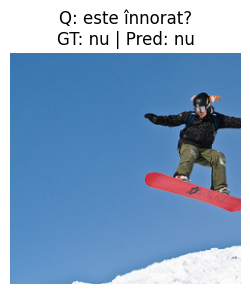

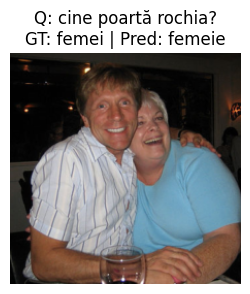

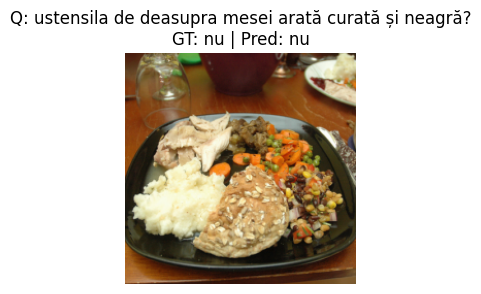

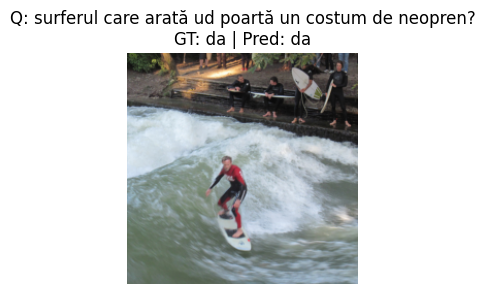

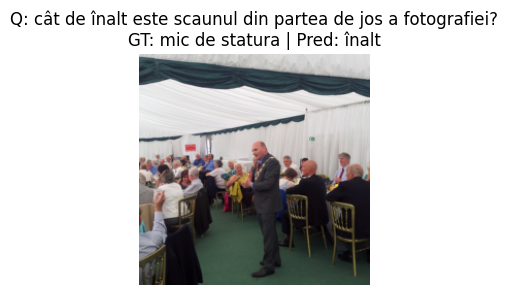

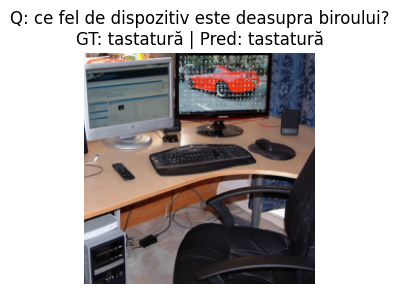

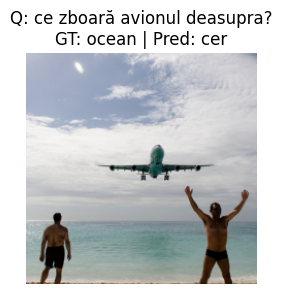

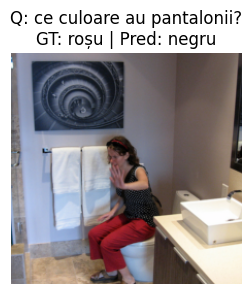

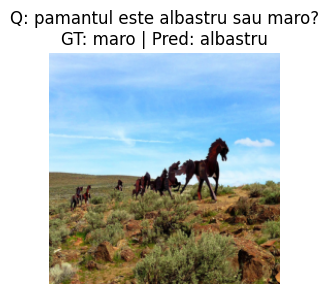

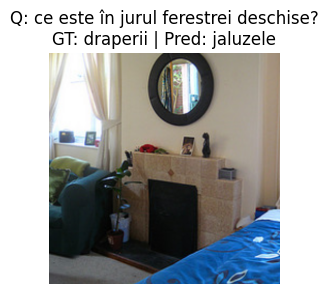

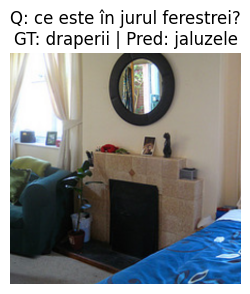

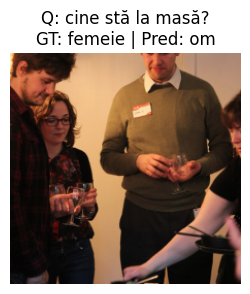

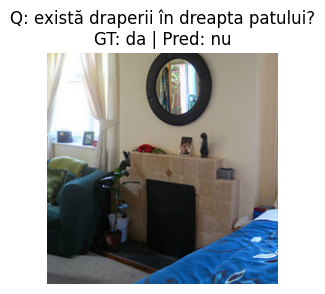

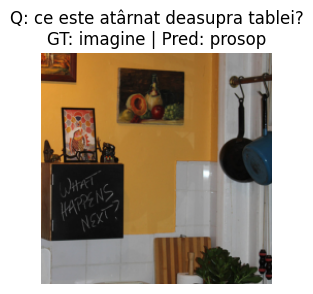

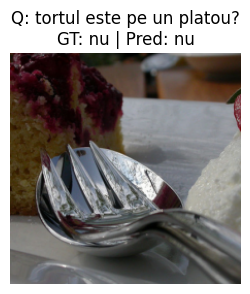

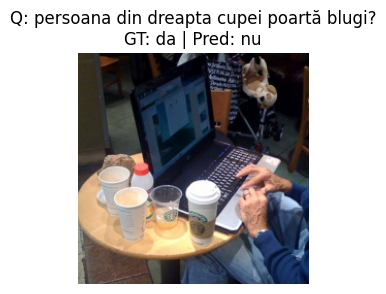

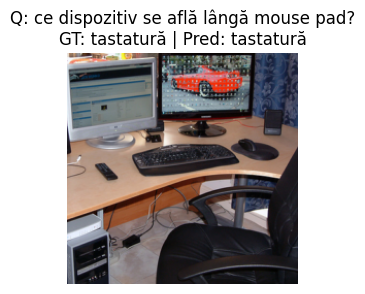

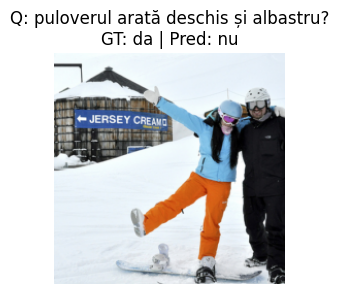

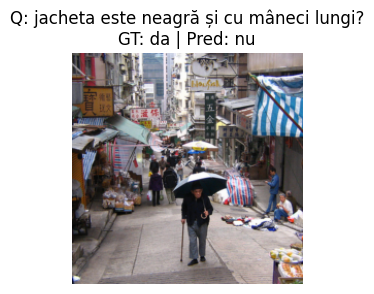

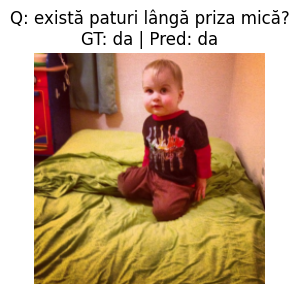

In [ ]:
import torch
import matplotlib.pyplot as plt


# 1) Prepare everything
# device   = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# # assume you have:
# #   test_loader    → DataLoader(test_dataset, batch_size=..., shuffle=False, ...)
# #   idx2answer     → dict mapping label idx → answer string
# #   your_model     → an instance of your fusion model class

# # load your trained weights
# ckpt_path       = " /content/drive/MyDrive/tb_runs/late-mamaba-cased/late-mamaba-casedt-best-resnet-robert-gelu.ckpt"            # or .pt
# your_model.load_state_dict(torch.load(ckpt_path, map_location=device))
# your_model.to(device).eval()

# 2) Inference loop over a few batches
num_show = 20
shown    = 0

with torch.no_grad():
    for batch in test_loader:
        imgs  = batch["image"].to(device)        # [B,3,224,224]
        qids  = batch["input_ids"].to(device)    # [B, max_len]
        masks = batch["attention_mask"].to(device)
        labels= batch["label"].to(device)        # [B]

        # forward
        logits    = lit_model(imgs, qids, masks)       # [B, num_classes]
        preds     = logits.argmax(dim=1)                # [B]

        # bring back to CPU / numpy for plotting
        imgs_cpu  = imgs.cpu()
        preds_cpu = preds.cpu().tolist()
        labels_cpu= labels.cpu().tolist()

        # decode each and show
        for img, qid, mask, pred_i, true_i in zip(
                imgs_cpu, qids.cpu(), masks.cpu(), preds_cpu, labels_cpu
        ):
            # decode question text
            question = tokenizer.decode(
                qid[mask.bool()],                       # only non-masked tokens
                skip_special_tokens=True
            )
            # map idx→answer
            pred_ans  = idx2answer[pred_i]
            true_ans  = idx2answer[true_i]

            # de-normalize & plot image
            mv_cfg = mamba.config
            mean   = torch.tensor(mv_cfg.mean).view(3,1,1)
            std    = torch.tensor(mv_cfg.std ).view(3,1,1)

            img_np = (img * std + mean).permute(1,2,0).clamp(0,1).numpy()
            img_np = img_np.clip(0,1)

            plt.figure(figsize=(3,3))
            plt.imshow(img_np)
            plt.axis("off")
            plt.title(f"Q: {question}\nGT: {true_ans} | Pred: {pred_ans}")
            plt.show()

            shown += 1
            if shown >= num_show:
                break
        if shown >= num_show:
            break


In [ ]:
# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = LateFusionModel().to(device)  # or LateFusionModel()
criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=weight_tensor)
optimizer = optim.AdamW(model.parameters(), lr=Config.learning_rate, weight_decay=1e-5)

# Add learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',  # Monitor accuracy
    factor=Config.scheduler_factor,
    patience=Config.patience,  # More frequent than early stopping
    threshold=Config.scheduler_threshold,
    min_lr=Config.min_lr,
    verbose=True
)

# Early stopping variables
best_acc = 0.0
epochs_no_improve = 0
early_stop = False


In [ ]:
from sklearn.metrics import accuracy_score
import torch

def sanity_overfit_on_batch(model, batch, device="cuda", num_iters=100, lr=3e-4):
    device = torch.device(device if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.train()

    # Use only this batch
    batch = {k: v.to(device) for k, v in batch.items()}
    inputs = {k: v for k, v in batch.items() if k != "label"}
    labels = batch["label"]

    # Optimizer & loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    print("🚨 Sanity Overfit Test on One Batch")
    for i in range(1, num_iters + 1):
        optimizer.zero_grad()
        outputs = model(**inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        preds = torch.argmax(outputs, dim=1)
        acc = (preds == labels).float().mean().item()

        print(f"[{i}/{num_iters}] Loss: {loss.item():.4f} | Acc: {acc:.4f}")


In [ ]:
# Grab a single batch from your train loader
single_batch = next(iter(train_loader))

# Run sanity check
sanity_overfit_on_batch(model, single_batch)


🚨 Sanity Overfit Test on One Batch
[1/100] Loss: 7.4604 | Acc: 0.0000
[2/100] Loss: 7.3988 | Acc: 0.0078
[3/100] Loss: 7.3234 | Acc: 0.0078
[4/100] Loss: 7.2157 | Acc: 0.0312
[5/100] Loss: 7.0961 | Acc: 0.0859
[6/100] Loss: 6.9188 | Acc: 0.1094
[7/100] Loss: 6.7462 | Acc: 0.1094
[8/100] Loss: 6.4861 | Acc: 0.1875
[9/100] Loss: 6.2336 | Acc: 0.1016
[10/100] Loss: 5.8422 | Acc: 0.1406
[11/100] Loss: 5.4805 | Acc: 0.0781
[12/100] Loss: 5.1172 | Acc: 0.0781
[13/100] Loss: 4.8348 | Acc: 0.0547
[14/100] Loss: 4.4487 | Acc: 0.1172
[15/100] Loss: 4.1748 | Acc: 0.2109
[16/100] Loss: 4.0081 | Acc: 0.2656
[17/100] Loss: 3.7211 | Acc: 0.2656
[18/100] Loss: 3.4571 | Acc: 0.3438
[19/100] Loss: 3.3525 | Acc: 0.4219
[20/100] Loss: 3.0022 | Acc: 0.6562
[21/100] Loss: 2.8392 | Acc: 0.5625
[22/100] Loss: 2.6263 | Acc: 0.7109
[23/100] Loss: 2.3933 | Acc: 0.7969
[24/100] Loss: 2.2522 | Acc: 0.7969
[25/100] Loss: 2.1490 | Acc: 0.8438
[26/100] Loss: 1.9228 | Acc: 0.8906
[27/100] Loss: 1.8460 | Acc: 0.8750
[2

KeyboardInterrupt: 

In [ ]:
# how many labels do you actually have?
n_labels = len(answer2idx)
print("Answer2idx size:", n_labels)

# what’s your model’s last‐layer out_features?
head = lit_model.backbone.classifier[-1]
print("Head out_features:", head.out_features)

assert head.out_features == n_labels, (
    f"Head dim ({head.out_features}) ≠ #labels ({n_labels})"
)


Answer2idx size: 1734
Head out_features: 1734


In [ ]:
batch = next(iter(train_loader))
imgs = batch["image"].to(device)
ids  = batch["input_ids"].to(device)
mask = batch["attention_mask"].to(device)
labs = batch["label"].to(device)

with torch.no_grad():
    logits = lit_model.backbone(imgs, ids, mask)
    preds  = logits.argmax(dim=1)

print("Batch labels:", torch.unique(labs))
print("Batch preds: ", torch.unique(preds))
print("Logits shape:", logits.shape)


Batch labels: tensor([   5,   27,   48,   58,   66,   79,   88,   90,  131,  145,  159,  161,
         177,  189,  196,  201,  202,  204,  208,  211,  213,  217,  223,  231,
         256,  261,  283,  287,  302,  322,  338,  339,  346,  347,  378,  385,
         394,  396,  426,  436,  440,  464,  519,  534,  558,  580,  607,  615,
         620,  623,  630,  646,  651,  691,  695,  702,  715,  721,  795,  813,
         818,  825,  828,  869,  872,  883,  913,  914,  917,  936,  952,  962,
         983,  985,  991, 1029, 1041, 1045, 1058, 1073, 1085, 1105, 1108, 1111,
        1119, 1162, 1171, 1183, 1200, 1204, 1209, 1276, 1278, 1279, 1301, 1303,
        1308, 1309, 1329, 1354, 1383, 1389, 1411, 1419, 1420, 1421, 1434, 1453,
        1458, 1489, 1490, 1492, 1532, 1541, 1554, 1563, 1585, 1625, 1626, 1653,
        1658, 1672, 1696, 1707], device='cuda:0')
Batch preds:  tensor([1724, 1725, 1727, 1728, 1729, 1730, 1731, 1732], device='cuda:0')
Logits shape: torch.Size([128, 1734])
